Ten notebook jest przeznaczony do badania algorytmów na zbiorach tekstowych **BBC News**

# BBC News Embeddings

Ten zbiór danych składa się z 2225 dokumentów ze strony BBC news odnoszących się do 5 obszrów tematycznych z lat 2004-2005


1.  **Wektoryzacja tesktów** tworzymy reprezentacje wektorowe na dwa sposoby, źeby pokazać,
 źe na późniejszą redukcję wymiarów duźy wpływ ma tekźe awybór algorytmu, który tworzt wektory

- paragraph-embedddingi MiniLM https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2

- TF-IDF

2.

In [3]:
import pandas as pd
from sentence_transformers import SentenceTransformer
from utils.scores import Dataset

## Załadowanie danych

In [15]:
bbc_data = pd.read_csv('./repo/data/bbc-news-data.csv', sep='\t')
bbc_data.head()

,category,filename,title,content
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...


In [16]:

model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [20]:
embeddings = []
for category, content in bbc_data[['category', 'content']].values:
    embedding = model.encode(content)
    embeddings.append(embedding)


bbc_data['embedding'] = embeddings
bbc_data.head()


,category,filename,title,content,embedding
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...,"[-0.05098325, -0.0706684, 0.013510434, -0.0183..."
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...,"[0.0061863787, -0.04703158, -0.017026866, 0.00..."
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...,"[-0.0742608, 0.024880419, -0.014749312, 0.0010..."
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...,"[0.040098142, -0.023337694, -0.010271476, 0.03..."
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...,"[0.026878482, -0.053647403, -0.007522893, -0.0..."


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(bbc_data['content'])

bbc_data['tdidf_embedding'] = list(tfidf_matrix.toarray())
bbc_data.head()

,category,filename,title,content,embedding,tdidf_embedding
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...,"[-0.05098325, -0.0706684, 0.013510434, -0.0183...","[0.0, 0.021263676803950603, 0.0, 0.0, 0.0, 0.0..."
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...,"[0.0061863787, -0.04703158, -0.017026866, 0.00...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...,"[-0.0742608, 0.024880419, -0.014749312, 0.0010...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...,"[0.040098142, -0.023337694, -0.010271476, 0.03...","[0.0, 0.019997434150077344, 0.0, 0.0, 0.0, 0.0..."
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...,"[0.026878482, -0.053647403, -0.007522893, -0.0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


# LDA

In [52]:
import numpy as np
from utils.lda import my_lda
import pandas as pd
import sys
sys.modules['utils.lda'].pd = pd
lda = my_lda(n_components=2)

X_text = np.array(bbc_data['embedding'].tolist())
y_text = bbc_data['category'].values

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_text, y_text, test_size=0.2, random_state=42)
X_train_lda, _ = lda.fit(X_train, y_train)

X_test_lda = np.dot(X_test, model_text_lda.lda_components)

/tmp/ipykernel_3387/2922206511.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  mapper = plt.cm.get_cmap('viridis', len(unique_categories))


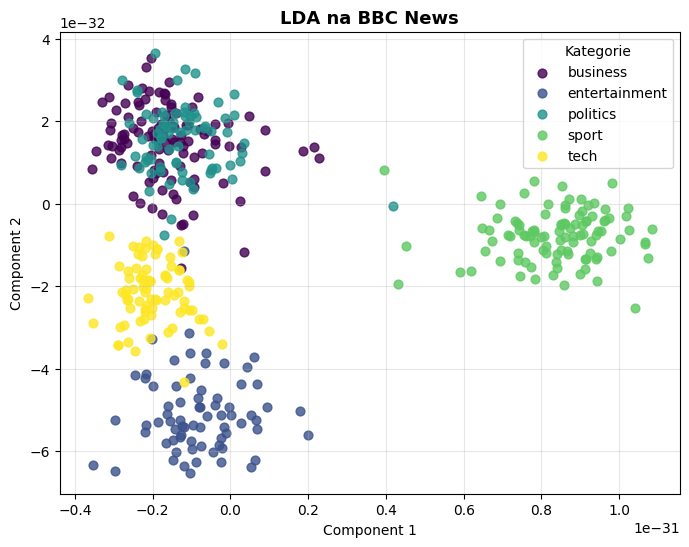

In [54]:
import matplotlib.pyplot as plt
unique_categories = sorted(list(set(y_test)))
mapper = plt.cm.get_cmap('viridis', len(unique_categories))

plt.figure(figsize=(8, 6))

for i, category in enumerate(unique_categories):
    indices = (y_test == category)

    plt.scatter(
        X_test_lda[indices, 0],
        X_test_lda[indices, 1],
        label=category,
        color=mapper(i),
        alpha=0.8,
        s=40
    )

plt.title("LDA na BBC News", fontsize=13, fontweight='bold')
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(title="Kategorie")
plt.grid(True, alpha=0.3)
plt.show()

In [56]:
from sklearn.manifold import trustworthiness

trust_lda = trustworthiness(X_test, X_test_lda, n_neighbors=5)
print(f"Trustworthiness dla LDA: {trust_lda:.4f}")

Trustworthiness dla LDA: 0.7465


In [58]:
from sklearn.metrics import normalized_mutual_info_score, silhouette_score, calinski_harabasz_score
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=len(set(y_test)),
    random_state=1,
    n_init=10
)

clusters = kmeans.fit_predict(X_test_lda)

nmi_pca = normalized_mutual_info_score(
    y_test,
    clusters
)

sil_pca = silhouette_score(
    X_test_lda,
    clusters
)

cal_har = calinski_harabasz_score(
    X_test_lda,
    clusters
)
print(f"NMI dla LDA: {nmi_pca:.4f}")
print(f"Silhouette dla LDA: {sil_pca:.4f}")
print(f"Calinski-Harabasz dla LDA: {cal_har:.4f}")

NMI dla LDA: 0.7552
Silhouette dla LDA: 0.5439
Calinski-Harabasz dla LDA: 1866.5598


# PCA

In [41]:
import numpy as np
from utils.pca import my_pca
import pandas as pd
import sys
sys.modules['utils.pca'].pd = pd
pca = my_pca(n_components=2)

X_text = np.array(bbc_data['embedding'].tolist())
y_text = bbc_data['category'].values

X_pca, df_pca = pca.fit(X_text)

/tmp/ipykernel_3387/2975951269.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  mapper = plt.cm.get_cmap('viridis', len(set(bbc_data['category'])))


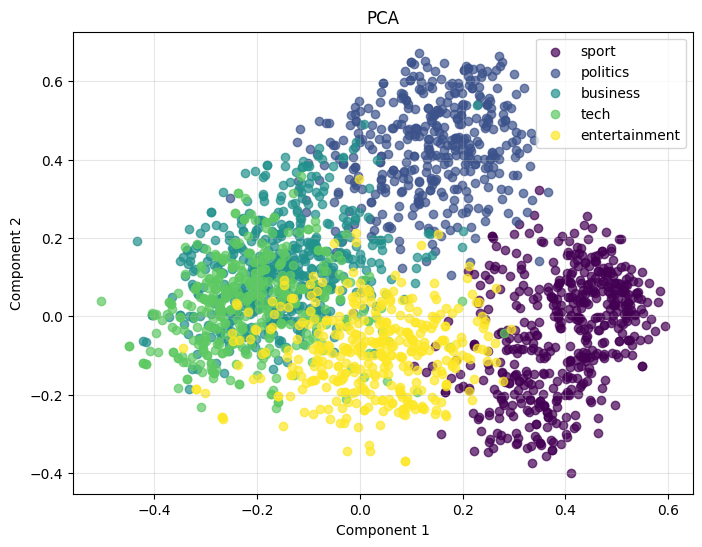

In [33]:
import matplotlib.pyplot as plt

mapper = plt.cm.get_cmap('viridis', len(set(bbc_data['category'])))

plt.figure(figsize=(8, 6))
for i, category in enumerate(set(bbc_data['category'])):
    indices = bbc_data['category'] == category
    plt.scatter(X_pca[indices, 0], X_pca[indices, 1], label=category, color=mapper(i), alpha=0.7)

plt.title("PCA na BBC News", fontsize=12)
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [37]:
from sklearn.manifold import trustworthiness

trust_lda = trustworthiness(X_text, X_pca, n_neighbors=5)
print(f"Trustworthiness dla PCA: {trust_lda:.4f}")

Trustworthiness dla PCA: 0.8097


In [38]:
from sklearn.metrics import normalized_mutual_info_score, silhouette_score, calinski_harabasz_score
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=10,
    random_state=1,
    n_init=10
)

clusters = kmeans.fit_predict(X_pca)

nmi_pca = normalized_mutual_info_score(
    y_text,
    clusters
)

sil_pca = silhouette_score(
    X_pca,
    clusters
)

cal_har = calinski_harabasz_score(
    X_pca,
    clusters
)
print(f"NMI dla PCA: {nmi_pca:.4f}")
print(f"Silhouette dla PCA: {sil_pca:.4f}")
print(f"Calinski-Harabasz dla PCA: {cal_har:.4f}")

NMI dla PCA: 0.5326
Silhouette dla PCA: 0.3703
Calinski-Harabasz dla PCA: 2569.5804


## Kernel PCA

/var/folders/9f/vftxvqkj6f9817yp5q44s5b80000gn/T/ipykernel_43308/4277864958.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  mapper = plt.cm.get_cmap('viridis', len(set(bbc_data['category'])))


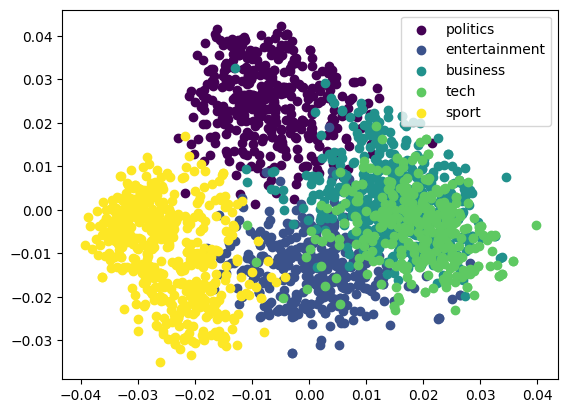

In [ ]:
import matplotlib.pyplot as plt
mapper = plt.cm.get_cmap('viridis', len(set(bbc_data['category'])))
for i, category in enumerate(set(bbc_data['category'])):
    indices = bbc_data['category'] == category
    plt.scatter(X_pca_2d[indices, 0], X_pca_2d[indices, 1], label=category, color=mapper(i))
plt.legend()